Project: Lung Cancer Data Analysis and Predictive Model

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sklearn as sk
import os
print(os.getcwd())

c:\Users\rg3ca\Documents\GitHub\DATA-601-Group-Project


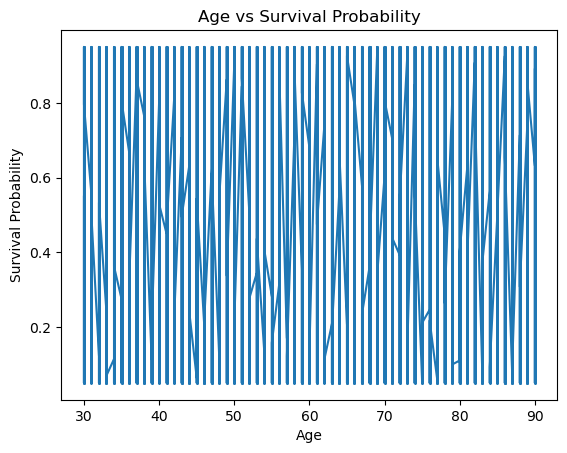

In [53]:
df_sorted = df.sort_values(by='Age')

x = df_sorted['Age']
y = df_sorted['5_Year_Survival_Probability']

plt.plot(x, y,marker = '.',ms = 1)
plt.xlabel("Age")
plt.ylabel("Survival Probability")
plt.title("Age vs Survival Probability")
plt.show()

In [ ]:
class DataHandler:

    def __init__(self,filepath):
        self.filepath = filepath
        self.df = None
        
    

    #load data
    def load(self):
        import pandas as pd
        self.df = pd.read_csv(self.filepath, keep_default_na=False)
        #keep_default_na=False is here so that "None" in the dataset isn't counted as a missing value

        #using this to visualize --Jayden 
        

    #clean data
    def clean(self):
        #remove duplicate datapoints
        self.df.drop_duplicates(inplace=True)

        #check for missing datapoints
        print("Number of missing datapoints: ", self.df.isnull().sum())
        


    #convert all categorical variables into discrete ordered/unordered values
    def transform(self, mapping):
        self.dfTransform = self.df.copy()
        #loop through mapping to adjust for ordered values
        for col, map_dict in mapping.items():
            if col in self.dfTransform:
                self.dfTransform[col] = self.dfTransform[col].map(map_dict)
        
        #convert all remaining object columns into unordered values
        self.dfTransform = pd.get_dummies(self.dfTransform,drop_first=False)
        
        return self.dfTransform.copy()
       

    #condense n values into m<n bins
    def bin_variable(self,column,bins,labels):
        if column in self.df:
            self.df[column+"_Bin"] = pd.cut(self.df[column],bins=bins,labels=labels,include_lowest=True)
            

    #seperate target variable from the rest of the dataset
    def set_target(self,target):
        self.y = self.df[target]
        self.x = self.df.drop(columns=[target])


    #return cleaned data
    def get_data(self):
        return self.df.copy()


    #return x
    def get_variables(self):
        return self.x.copy()
    
    
    #return y
    def get_target(self):
        return self.y.copy()
    

In [ ]:
class DataVisualizer:

    def __init__(self,df):
        self.df = df

    #histograms - int/float value variables
    def histogram(self, var, bins=None):
        self.df[var].hist(bins)
        plt.title(f'{var} Histogram')
        plt.xlabel(var)
        plt.ylabel("Amount")
        plt.show()

    #bar plot - categorical variables
    def bar_chart(self, var):
        self.df[var].value_counts().plot(kind='bar')
        plt.title(f'{var} Bar Chart')
        plt.xlabel(var)
        plt.ylabel("Amount")
        plt.show()

    #variable vs target box plot
    def variable_vs_target(self, var, target):
        sns.boxplot(x=target, y=var, data=self.df)
        plt.title(f'{var} Versus {target}')
        plt.xlabel(target)
        plt.ylabel(var)
        plt.show()

    #correlation heatmap
    def corr_matrix(self):
        plt.figure(figsize=(20,20))
        corr_mtx = self.df.corr()
        sns.heatmap(corr_mtx, cmap='coolwarm')
        plt.title("Correlation Matrix")
        plt.show()

    #find missing values w/ heatmap
    def missing(self):
        sns.heatmap(self.df.isnull(), cbar=False)
        plt.title("Missing Value Matrix")
        plt.show()

    #pie chart
    def pie_chart(self, var):
        self.df[var].value_counts().plot(kind='pie')
        plt.title(f'{var} Pie Chart')
        plt.xlabel(var)
        plt.ylabel("Amount")
        plt.show()


    #stacked bar
    def stacked_bar_chart(self, varTop, varBottom):
        fTable = pd.crosstab(self.df[varBottom], self.df[varTop])
        fTable.plot(kind='bar', stacked=True)
        plt.title(f'{varTop} and {varBottom} Bar Chart')
        plt.xlabel(varBottom)
        plt.ylabel("Amount")
        plt.legend(title=varTop)
        plt.show()

    #grouped bar
    def grouped_bar_chart(self, var1, var2):
        fTable = pd.crosstab(self.df[var2], self.df[var1])
        fTable.plot(kind='bar', stacked=False)
        plt.title(f'{var1} and {var2} Bar Chart')
        plt.xlabel(var2)
        plt.ylabel("Amount")
        plt.legend(title=var1)
        plt.show()


    # Mutual Information Correlation Chart
    def mutual_info_corr(self, target_column, additional_drop = []):

        from sklearn.feature_selection import mutual_info_classif
        drop = additional_drop + [target_column]
        X = self.df.drop(columns=drop)

        Y = self.df[target_column]

        mi_scores = mutual_info_classif(X, Y, discrete_features = True)

        mi_df = pd.DataFrame({'Variables': X.columns, 'Mutual Information Scores': mi_scores})
        mi_df = mi_df.sort_values(by='Mutual Information Scores', ascending=False).head(20)

        plt.figure(figsize=(10, 8))
        sns.barplot(data=mi_df, x='Mutual Information Scores', y='Variables')
        plt.title(f"Features Impacting {target_column} using Mutual Information")
        plt.xlabel("Impact")
        plt.show()

In [149]:
lungCancerData = DataHandler("lung_cancer_prediction.csv")
lungCancerData.load()
lungCancerData.clean()

#add a bin for age so we can make an analysis based on age groups
lungCancerData.bin_variable("Age",[29,60,91],[0,1])

#these variables have to be ordered in the analysis
lungMap = {'Air_Pollution_Exposure': {'Low':0, 'Medium':1, 'High':2},
        'Socioeconomic_Status': {'Low':0, 'Middle':1, 'High':2},
        'Stage_at_Diagnosis': {'I':1, 'II':2, 'III':3, 'IV':4},
        'Second_Hand_Smoke': {'Yes':1, 'No':0},
        'Indoor_Smoke_Exposure': {'Yes':1, 'No':0},
        'Rural_or_Urban': {'Rural':0, 'Urban':1},
        'Gender': {'Male':1, 'Female':0},
        'Healthcare_Access': {'Good':2, 'Limited':1, 'Poor':0},
        'Insurance_Coverage': {'Yes':1, 'No':0},
        'Screening_Availability': {'Yes':1, 'No':0},
        'Clinical_Trial_Access': {'Yes':1, 'No':0},
        'Delay_in_Diagnosis': {'Yes':1, 'No':0},
        'Tobacco_Marketing_Exposure': {'Yes':1, 'No':0},
        'Family_History': {'Yes':1, 'No':0},
        'Treatment_Access': {'Full':2, 'Partial':1, 'None':0},
        'Smoking_Status': {'Non-Smoker':0, 'Former Smoker':1, 'Smoker':2},
        'Occupation_Exposure': {'Yes':1, 'No':0},
        'Cancer_Type': {'SCLC':1, 'NSCLC':0},
        'Language_Barrier': {'Yes':1, 'No':0},
        'Final_Prediction': {'Yes':1, 'No':0}
            }




#convert data types from dataset to booleans for analysis
lungTransform = lungCancerData.transform(lungMap)




Number of missing datapoints:  Country                        0
Age                            0
Gender                         0
Smoking_Status                 0
Second_Hand_Smoke              0
Air_Pollution_Exposure         0
Occupation_Exposure            0
Rural_or_Urban                 0
Socioeconomic_Status           0
Healthcare_Access              0
Insurance_Coverage             0
Screening_Availability         0
Stage_at_Diagnosis             0
Cancer_Type                    0
Mutation_Type                  0
Treatment_Access               0
Clinical_Trial_Access          0
Language_Barrier               0
Mortality_Risk                 0
5_Year_Survival_Probability    0
Delay_in_Diagnosis             0
Family_History                 0
Indoor_Smoke_Exposure          0
Tobacco_Marketing_Exposure     0
Final_Prediction               0
dtype: int64


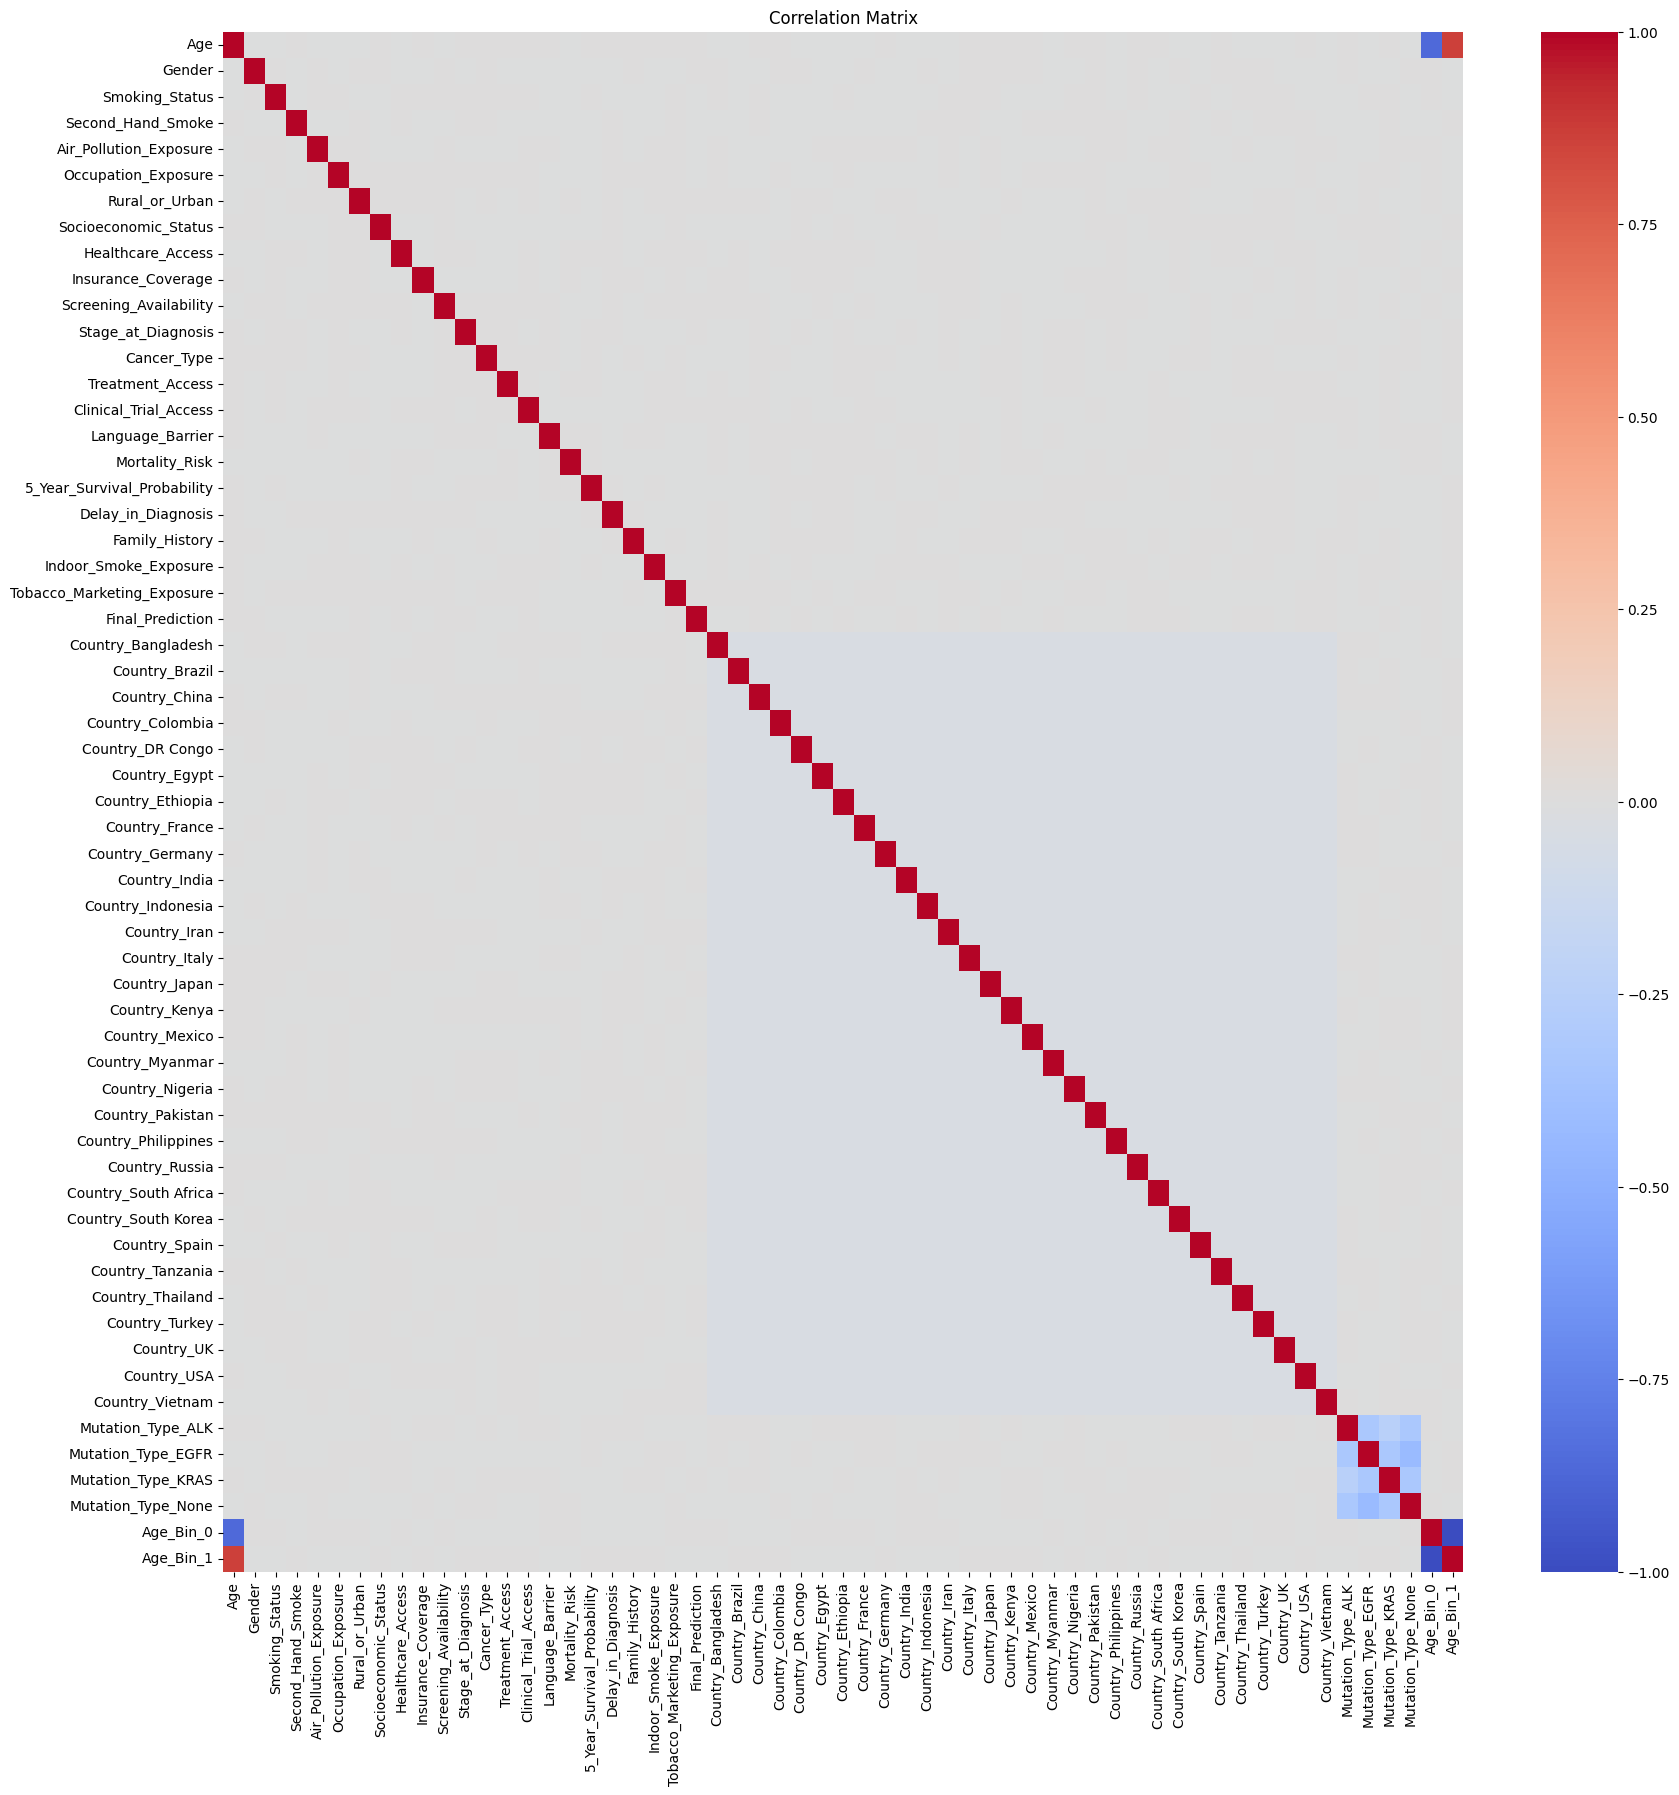

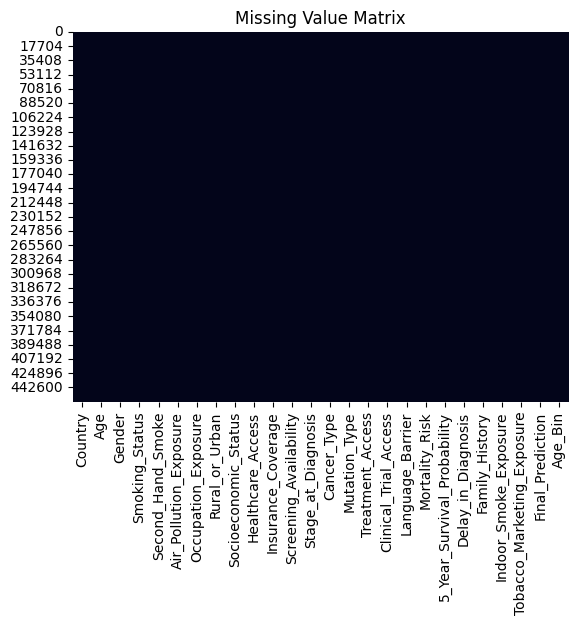

In [152]:
lungDF = lungCancerData.get_data()
lungVisual = DataVisualizer(lungDF)
lungVisualTrans = DataVisualizer(lungTransform)
lungVisualTrans.corr_matrix()
lungVisual.missing()


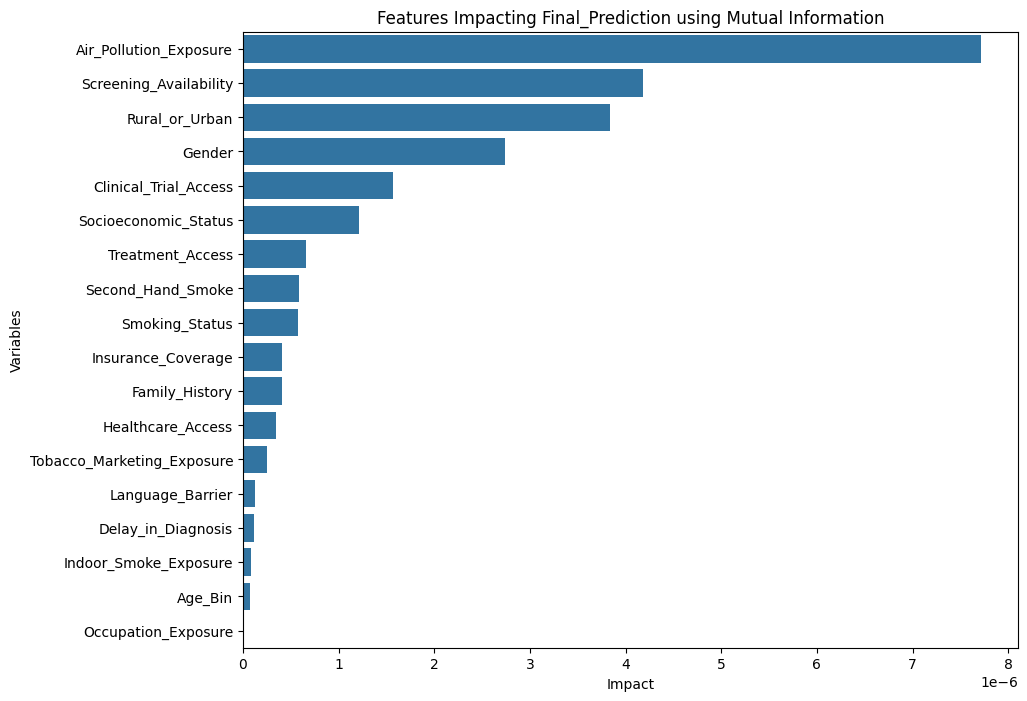

In [151]:
lungVisual.mutual_info_corr('Final_Prediction',['5_Year_Survival_Probability','Mortality_Risk','Country','Mutation_Type','Stage_at_Diagnosis','Cancer_Type','Age'])

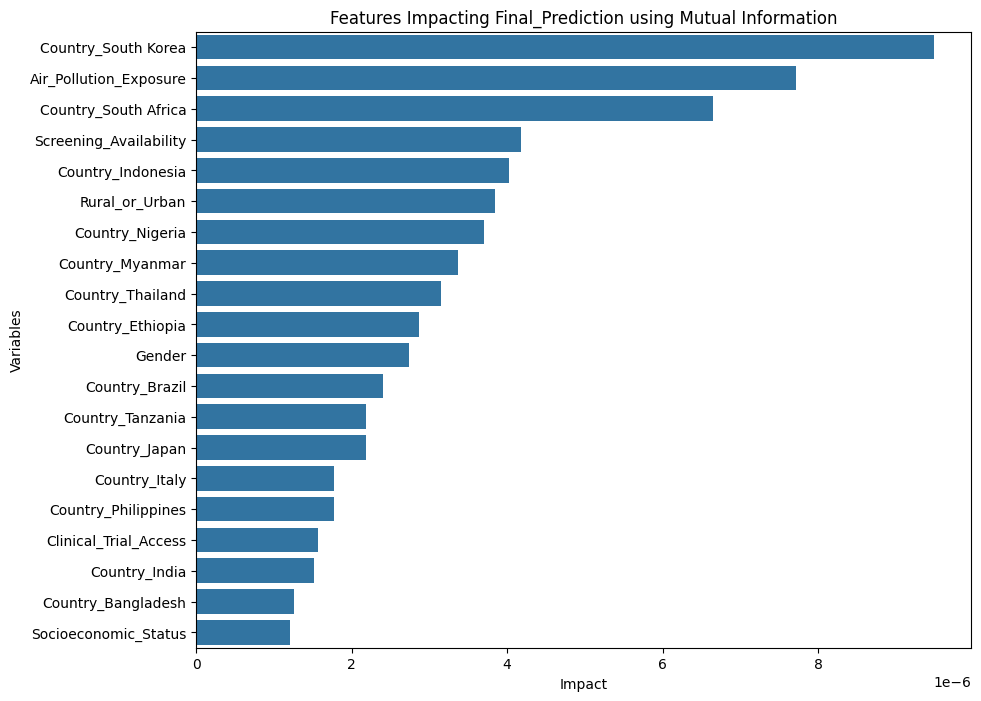

In [155]:
lungVisualTrans.mutual_info_corr('Final_Prediction',['5_Year_Survival_Probability','Mortality_Risk','Mutation_Type_ALK', 'Mutation_Type_EGFR',
                                                    'Mutation_Type_KRAS', 'Mutation_Type_None','Stage_at_Diagnosis','Cancer_Type','Age'])

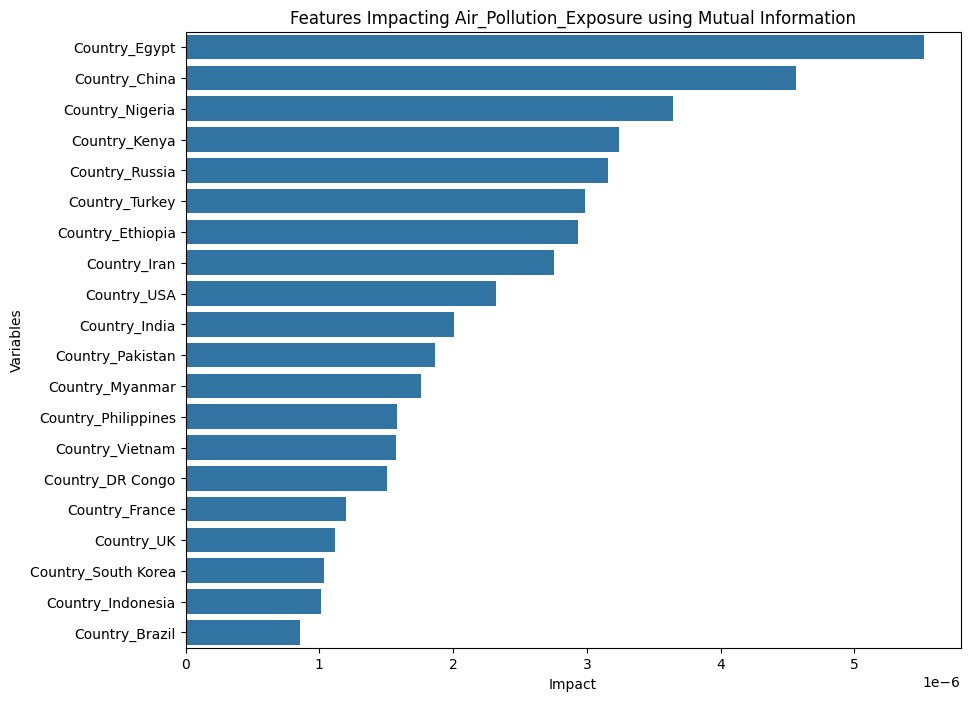

In [156]:
lungVisualTrans.mutual_info_corr('Air_Pollution_Exposure',['Age', 'Gender', 'Smoking_Status', 'Second_Hand_Smoke',
       'Air_Pollution_Exposure', 'Occupation_Exposure', 'Rural_or_Urban',
       'Socioeconomic_Status', 'Healthcare_Access', 'Insurance_Coverage',
       'Screening_Availability', 'Stage_at_Diagnosis', 'Cancer_Type',
       'Treatment_Access', 'Clinical_Trial_Access', 'Language_Barrier',
       'Mortality_Risk', '5_Year_Survival_Probability', 'Delay_in_Diagnosis',
       'Family_History', 'Indoor_Smoke_Exposure', 'Tobacco_Marketing_Exposure',
       'Final_Prediction','Mutation_Type_ALK', 'Mutation_Type_EGFR',
       'Mutation_Type_KRAS', 'Mutation_Type_None', 'Age_Bin_0', 'Age_Bin_1'])

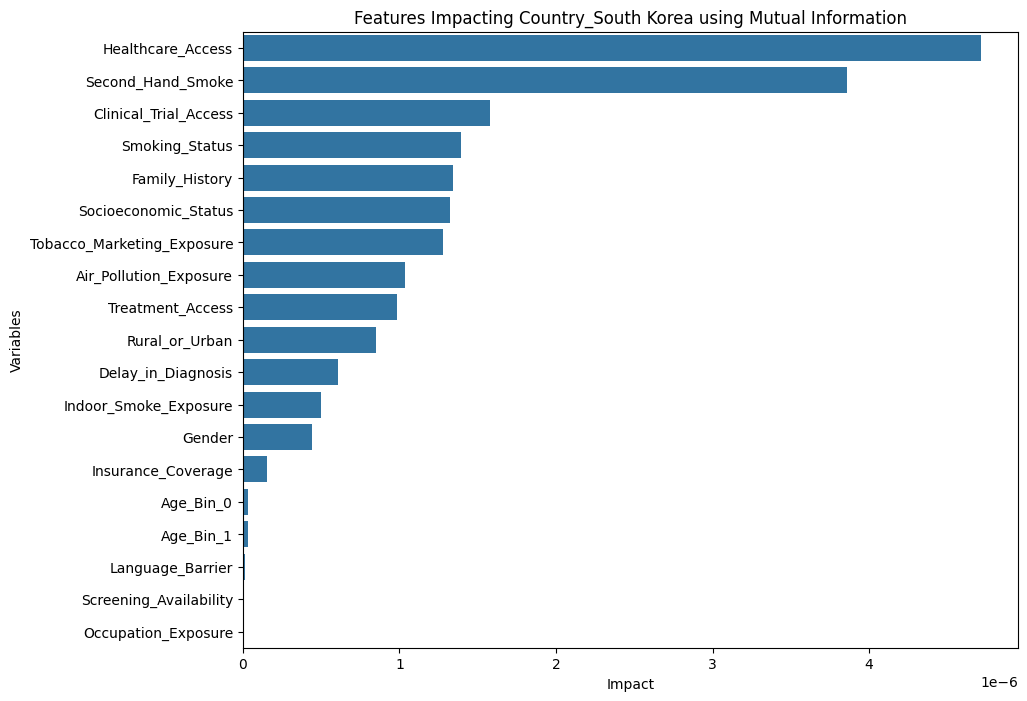

In [ ]:
lungVisualTrans.mutual_info_corr('Country_South Korea',['5_Year_Survival_Probability','Mortality_Risk','Country_Bangladesh', 'Country_Brazil',
       'Country_China', 'Country_Colombia', 'Country_DR Congo',
       'Country_Egypt', 'Country_Ethiopia', 'Country_France',
       'Country_Germany', 'Country_India', 'Country_Indonesia', 'Country_Iran',
       'Country_Italy', 'Country_Japan', 'Country_Kenya', 'Country_Mexico',
       'Country_Myanmar', 'Country_Nigeria', 'Country_Pakistan',
       'Country_Philippines', 'Country_Russia', 'Country_South Africa',
        'Country_Spain', 'Country_Tanzania',
       'Country_Thailand', 'Country_Turkey', 'Country_UK', 'Country_USA',
       'Country_Vietnam', 'Age', 'Final_Prediction','Mutation_Type_ALK', 'Mutation_Type_EGFR',
       'Mutation_Type_KRAS', 'Mutation_Type_None','Stage_at_Diagnosis','Cancer_Type' ])

In [154]:
lungTransform.columns

Index(['Age', 'Gender', 'Smoking_Status', 'Second_Hand_Smoke',
       'Air_Pollution_Exposure', 'Occupation_Exposure', 'Rural_or_Urban',
       'Socioeconomic_Status', 'Healthcare_Access', 'Insurance_Coverage',
       'Screening_Availability', 'Stage_at_Diagnosis', 'Cancer_Type',
       'Treatment_Access', 'Clinical_Trial_Access', 'Language_Barrier',
       'Mortality_Risk', '5_Year_Survival_Probability', 'Delay_in_Diagnosis',
       'Family_History', 'Indoor_Smoke_Exposure', 'Tobacco_Marketing_Exposure',
       'Final_Prediction', 'Country_Bangladesh', 'Country_Brazil',
       'Country_China', 'Country_Colombia', 'Country_DR Congo',
       'Country_Egypt', 'Country_Ethiopia', 'Country_France',
       'Country_Germany', 'Country_India', 'Country_Indonesia', 'Country_Iran',
       'Country_Italy', 'Country_Japan', 'Country_Kenya', 'Country_Mexico',
       'Country_Myanmar', 'Country_Nigeria', 'Country_Pakistan',
       'Country_Philippines', 'Country_Russia', 'Country_South Africa',
   

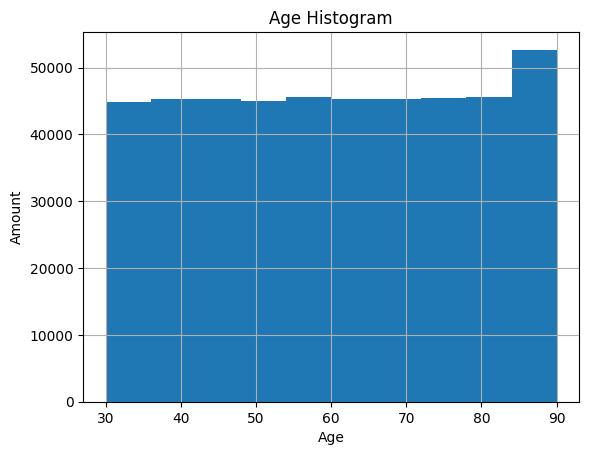

In [64]:
lungVisual.histogram("Age")


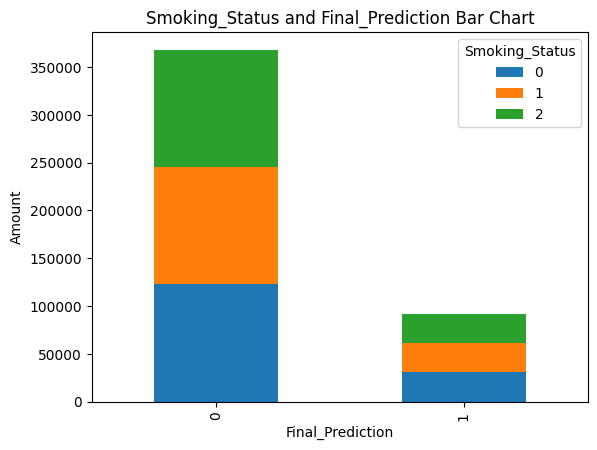

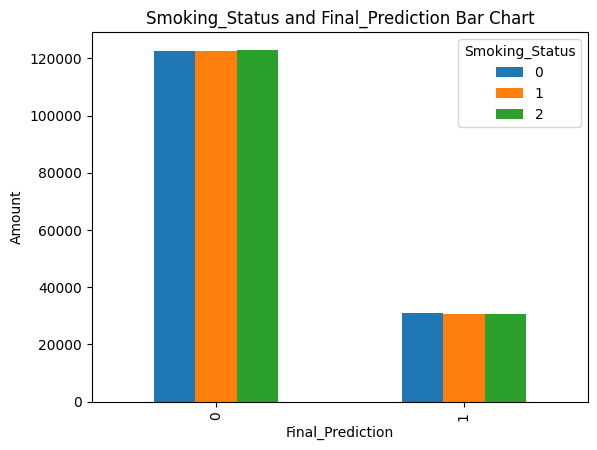

In [78]:
lungVisualTrans.stacked_bar_chart("Smoking_Status","Final_Prediction")
lungVisualTrans.grouped_bar_chart("Smoking_Status","Final_Prediction")

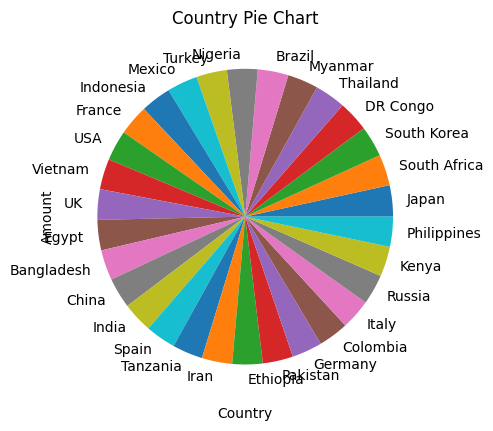

In [85]:
lungVisual.pie_chart("Country")
